In [1]:
from pathlib import Path 

import cv2 
import dlib
import IPython
from tqdm import tqdm 

In [2]:
def draw_faces(img, faces):
    for face in faces:
        x, y, w, h = face.rect.left(), face.rect.top(), face.rect.right(), face.rect.bottom()
        c = face.confidence
        # x, y, w, h = face.left(), face.top(), face.right(), face.bottom()
        cv2.rectangle(img, (x, y), (w, h), (0, 0, 255), 2)

In [3]:
def show_image(image):
    _, ret = cv2.imencode('.jpg', image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)

In [4]:
def show_faces(src):
    img = cv2.imread(f'../test_images/{src}')
    det = dlib.cnn_face_detection_model_v1('../data/mmod_human_face_detector.dat')
    faces = det(img)
    draw_faces(img, faces)
    show_image(img)

In [5]:
def show_by_name(name):
    fp = Path('../test_images').joinpath(name)
    img = cv2.imread(str(fp))
    show_image(img)

## Loading the Model

The GPU-based cnn model requires downloading the pre-traiend weights from http://dlib.net/files/mmod_human_face_detector.dat.bz2.

In [6]:
det = dlib.cnn_face_detection_model_v1('../data/mmod_human_face_detector.dat')

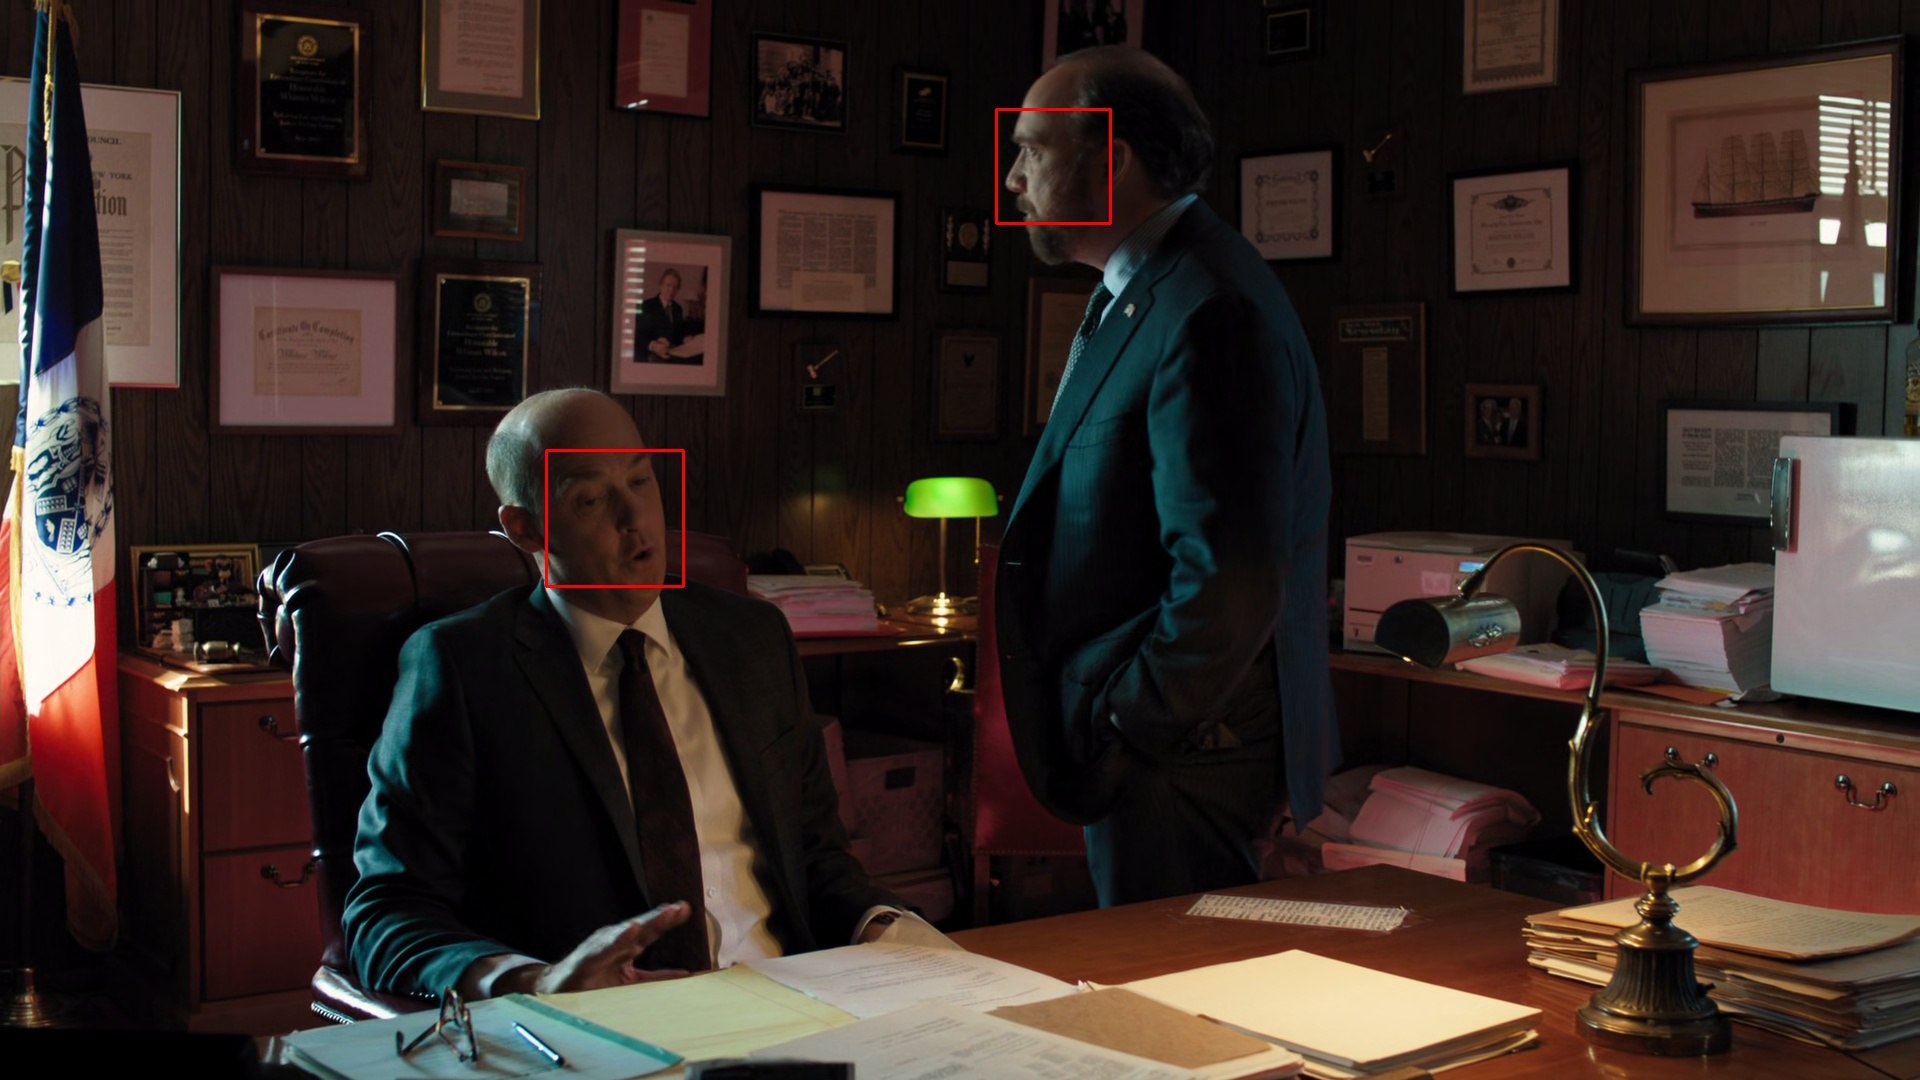

In [7]:
src = '../test_images/Billions.S01E10.1080p.BluRay.x265-RARBG_51504.png'
img = cv2.imread(str(src))
faces = det(img)
draw_faces(img, faces)
show_image(img)

## Upsampling
For smaller faces, dlib works better when the image is "upsampled." The issue with upsampling is that it increases processing time.

Dlib fails to find faces in the image below. 

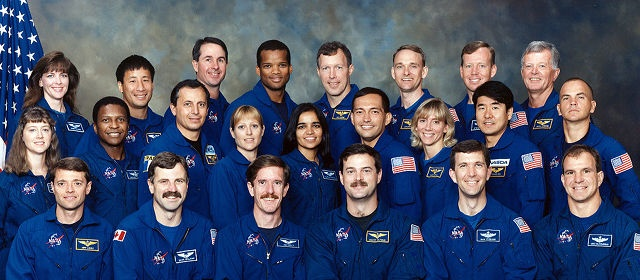

In [26]:
src = './images/img_2.jpg'
img = cv2.imread(str(src))
faces = det(img)
draw_faces(img, faces)
show_image(img)

If we upsample, however, dlib is able to find most if not all of the faces.

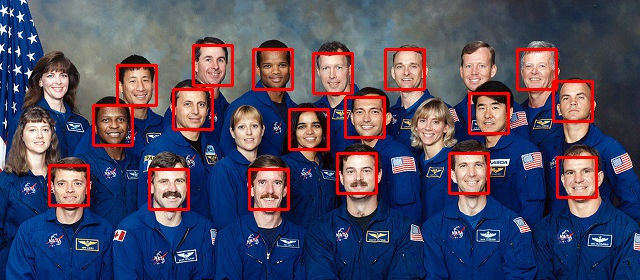

In [27]:
src = './images/img_2.jpg'
img = cv2.imread(str(src))
faces = det(img, 1)
draw_faces(img, faces)
show_image(img)

Upsampling again finds all the faces, though it finds one twice (this can be fixed by post-processing, however.)

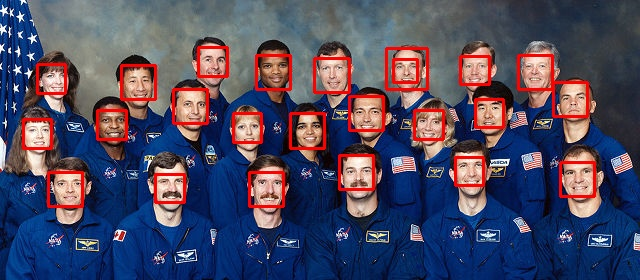

In [28]:
src = './images/img_2.jpg'
img = cv2.imread(str(src))
faces = det(img, 2)
draw_faces(img, faces)
show_image(img)

We can see the same thing in this sample image from congress.

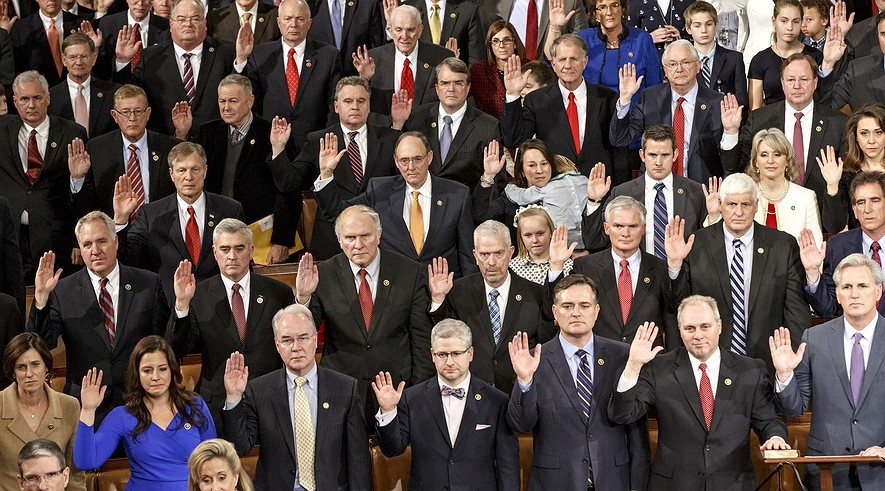

In [29]:
src = './images/img_3.jpg'
img = cv2.imread(str(src))
faces = det(img)
draw_faces(img, faces)
show_image(img)

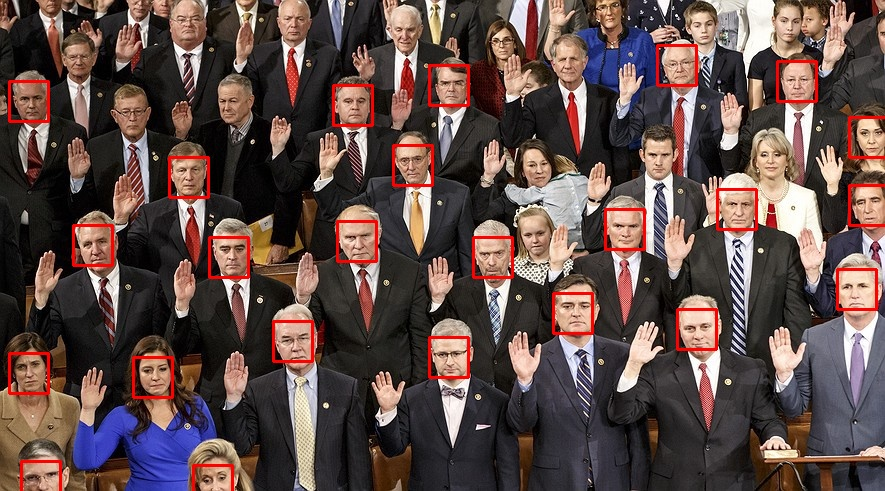

In [30]:
src = './images/img_3.jpg'
img = cv2.imread(str(src))
faces = det(img, 1)
draw_faces(img, faces)
show_image(img)

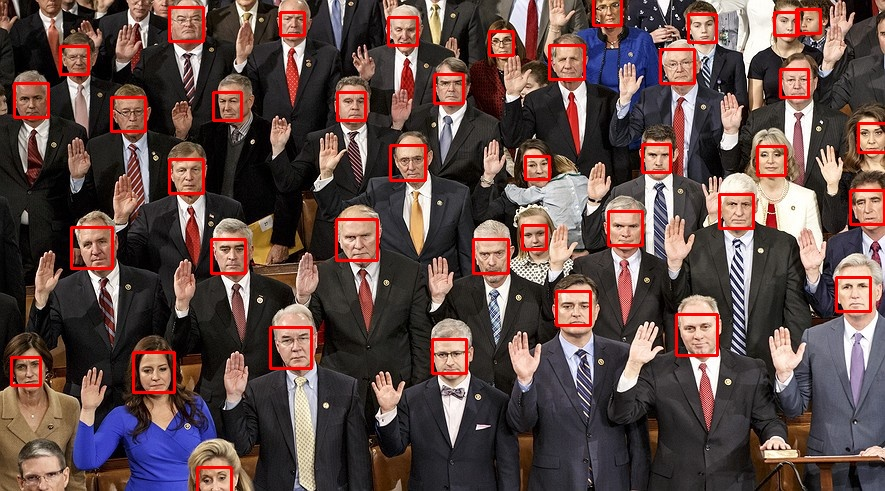

In [31]:
src = './images/img_3.jpg'
img = cv2.imread(str(src))
faces = det(img, 2)
draw_faces(img, faces)
show_image(img)

Upsampling twice catches all non-occluded faces. For large, frontal faces, no upsampling is needed. (For some reason dlib is not detecting the position all that accurately for large faces.)

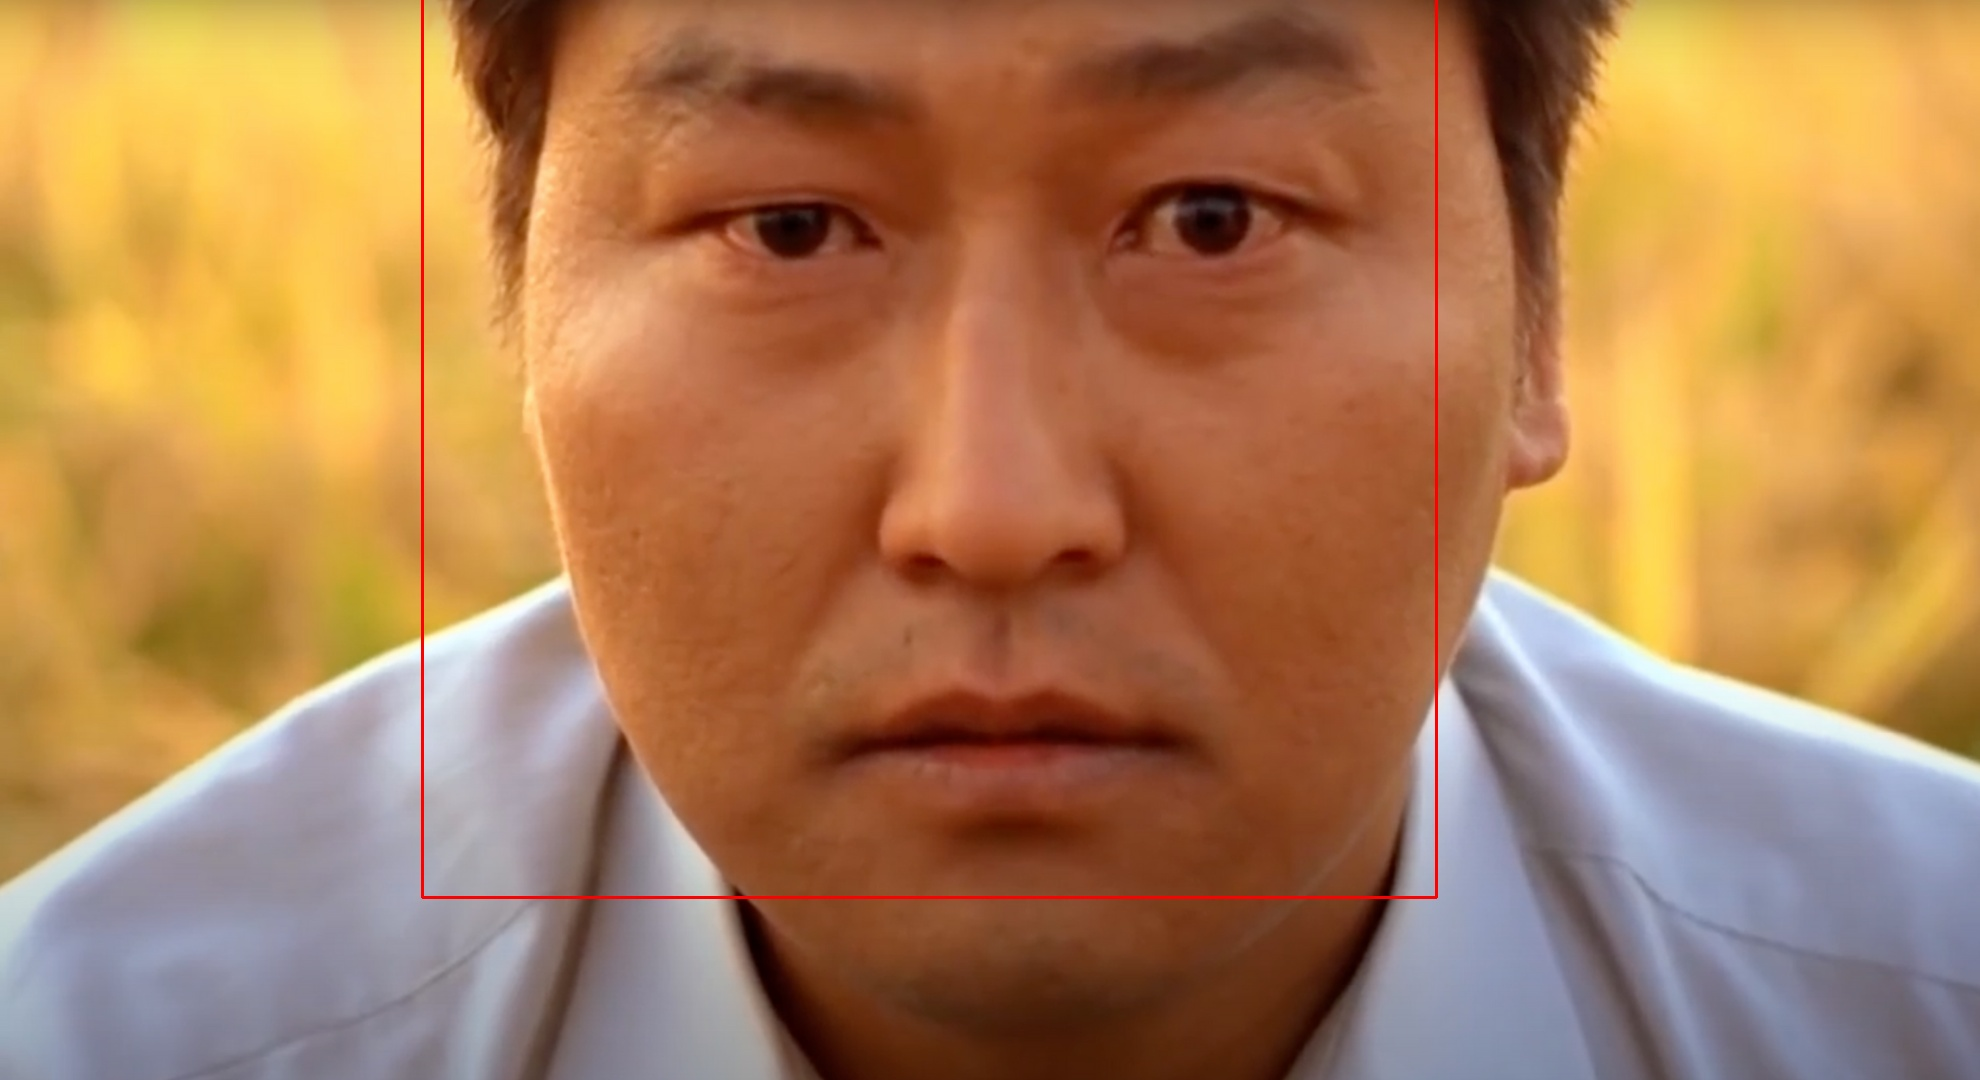

In [7]:
src = './images/img_4.jpg'
img = cv2.imread(str(src))
faces = det(img)
draw_faces(img, faces)
show_image(img)

For some reason, dlib is having issues with correctly positioning the bounding box. It's unclear why.

In [9]:
face = faces[0]
x, y, w, h = face.rect.left(), face.rect.top(), face.rect.right(), face.rect.bottom()
print(x, y, w, h)

422 -117 1436 897


The value for the top of the face is negative, but it may be estimating the position since the top of the face is cut off.

For extreme close-ups, it doesn't matter how many times the image is upsampled. Dlib will never detect these faces.

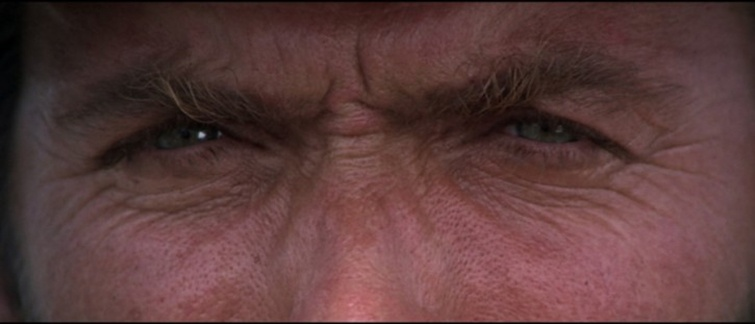

In [39]:
src = './images/img_5.jpg'
img = cv2.imread(str(src))
faces = det(img, 3)
draw_faces(img, faces)
show_image(img)

Dlib is able to detect faces at unusual angles, however, which is a key benefit of using the GPU accelerated model. The CPU-based HOG model can only detect frontal features. 

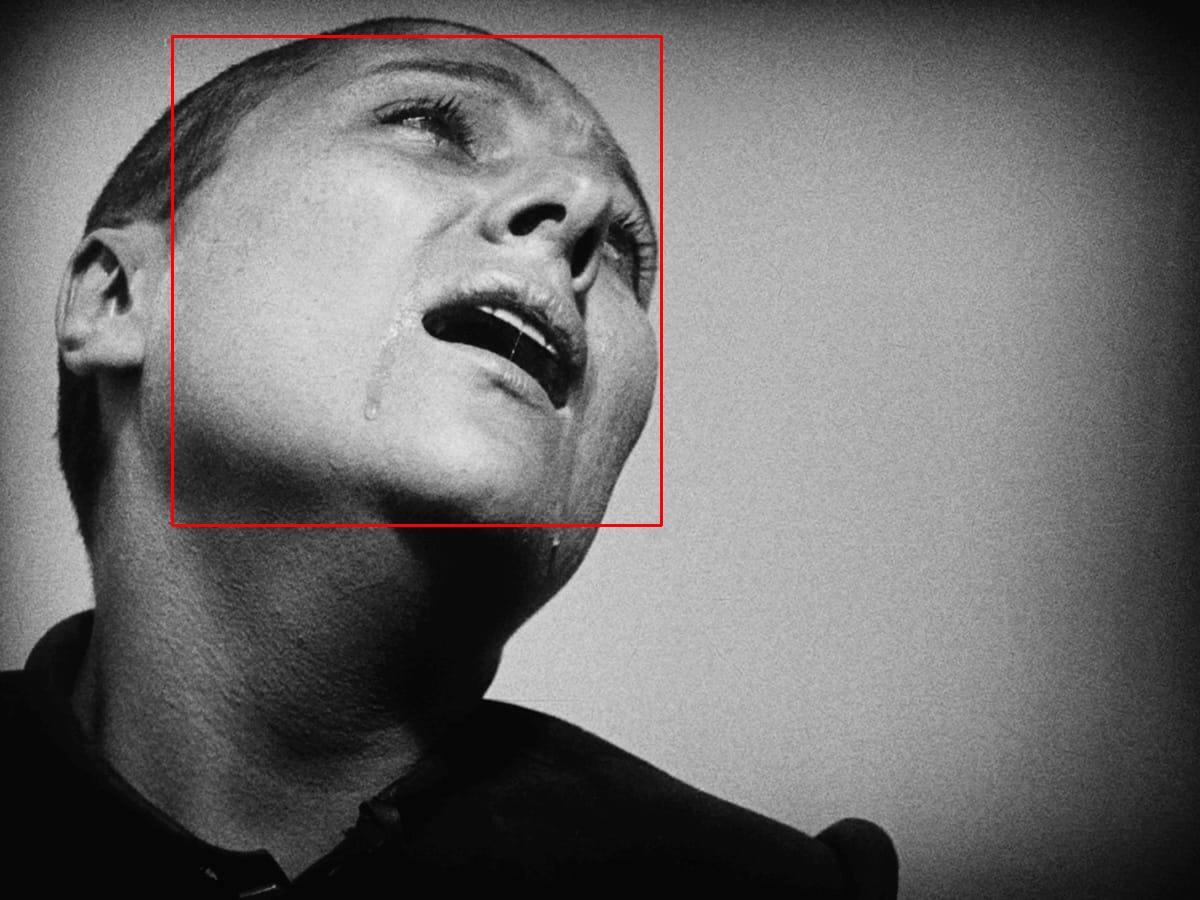

In [41]:
src = './images/img_6.jpg'
img = cv2.imread(str(src))
faces = det(img)
draw_faces(img, faces)
show_image(img)

## Processing Video

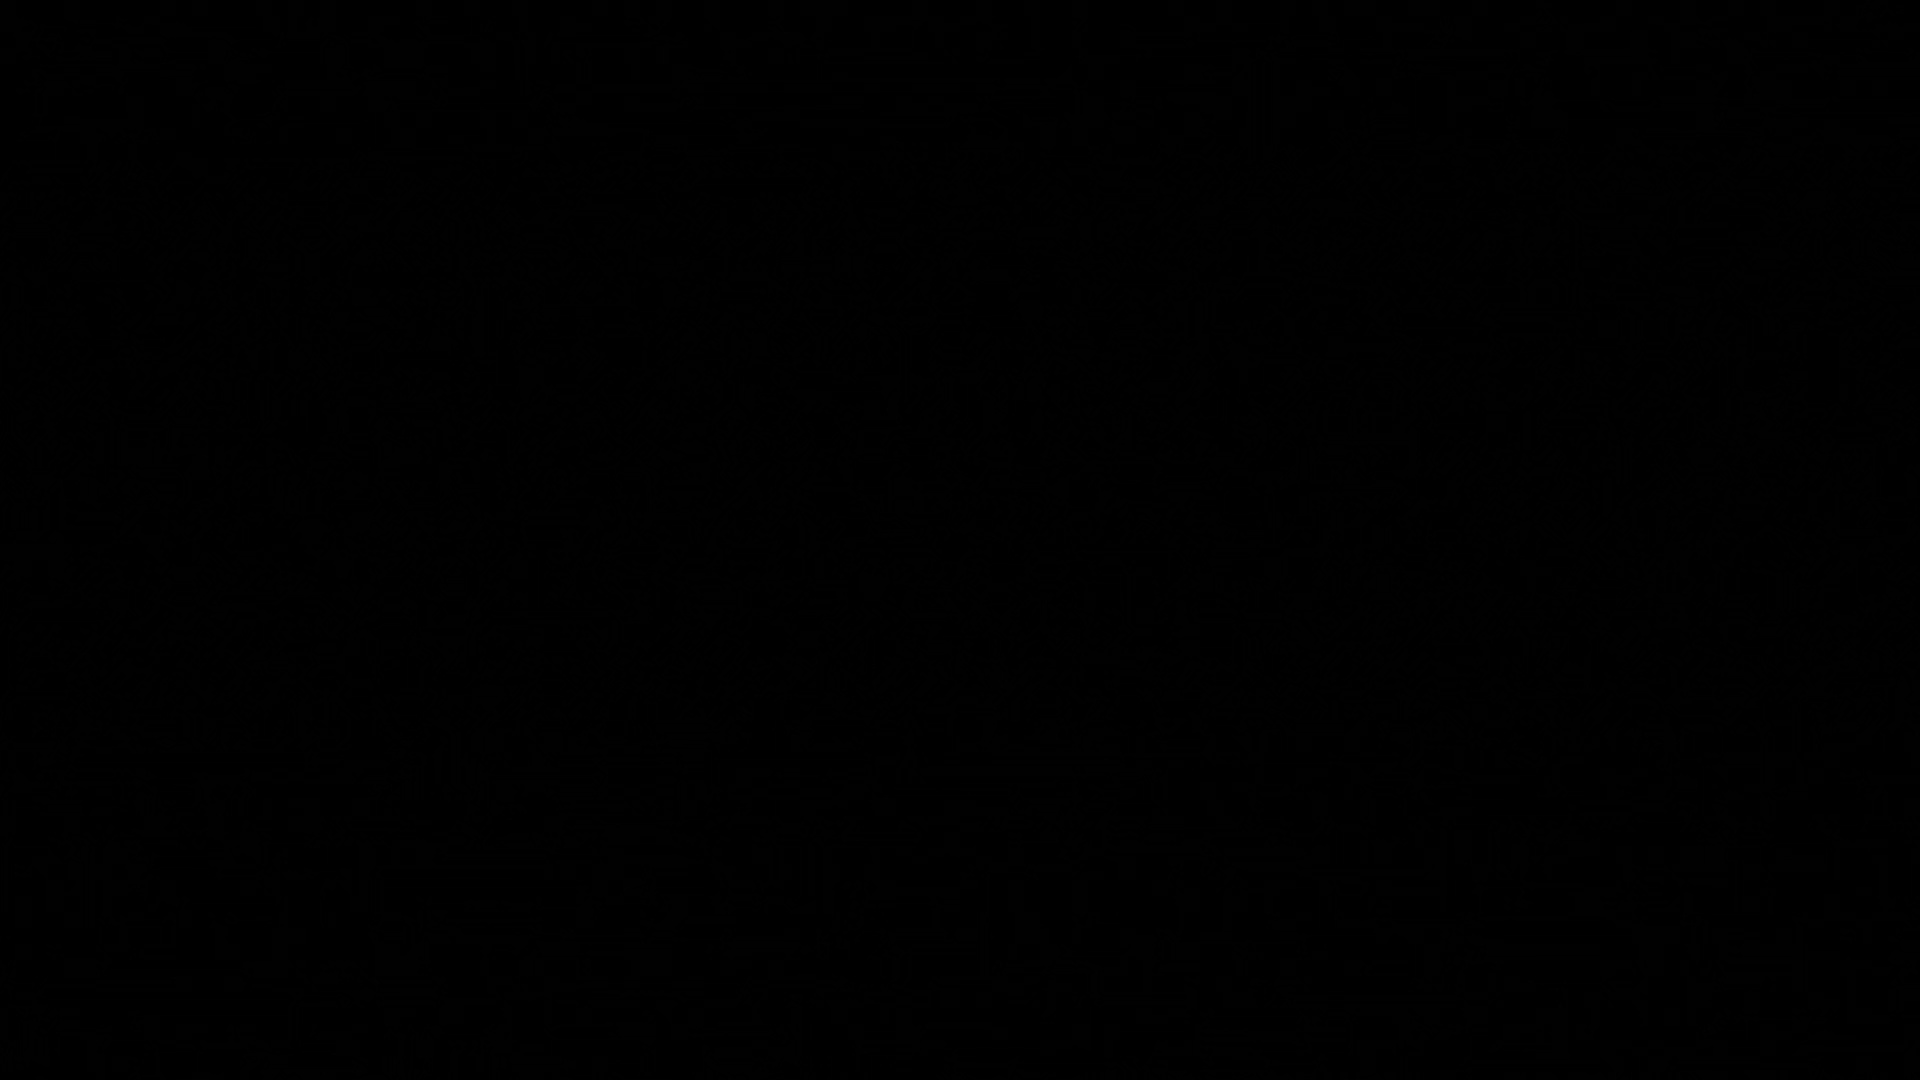

  2%|▏         | 1800/111290 [00:19<02:32, 719.82it/s]

In [9]:
cap = cv2.VideoCapture('./data/test.mkv')
_, frame = cap.read()
show_image(frame)

In [8]:
cnt = 0
framecount = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
pb = tqdm(total=framecount)
while True:
    if cnt % 24 == 0:
        _, frame = cap.read()
        img = frame
        # img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        faces = det(img)
        if len(faces) == 0:
            pb.update(1)
            cnt += 1
            continue
        draw_faces(img, faces)
        show_image(img)
        break
    cnt = cnt + 1
    pb.update(1)
print(cnt)

  2%|▏         | 1729/111290 [00:02<02:32, 719.82it/s]

KeyboardInterrupt: 

## Testing Images

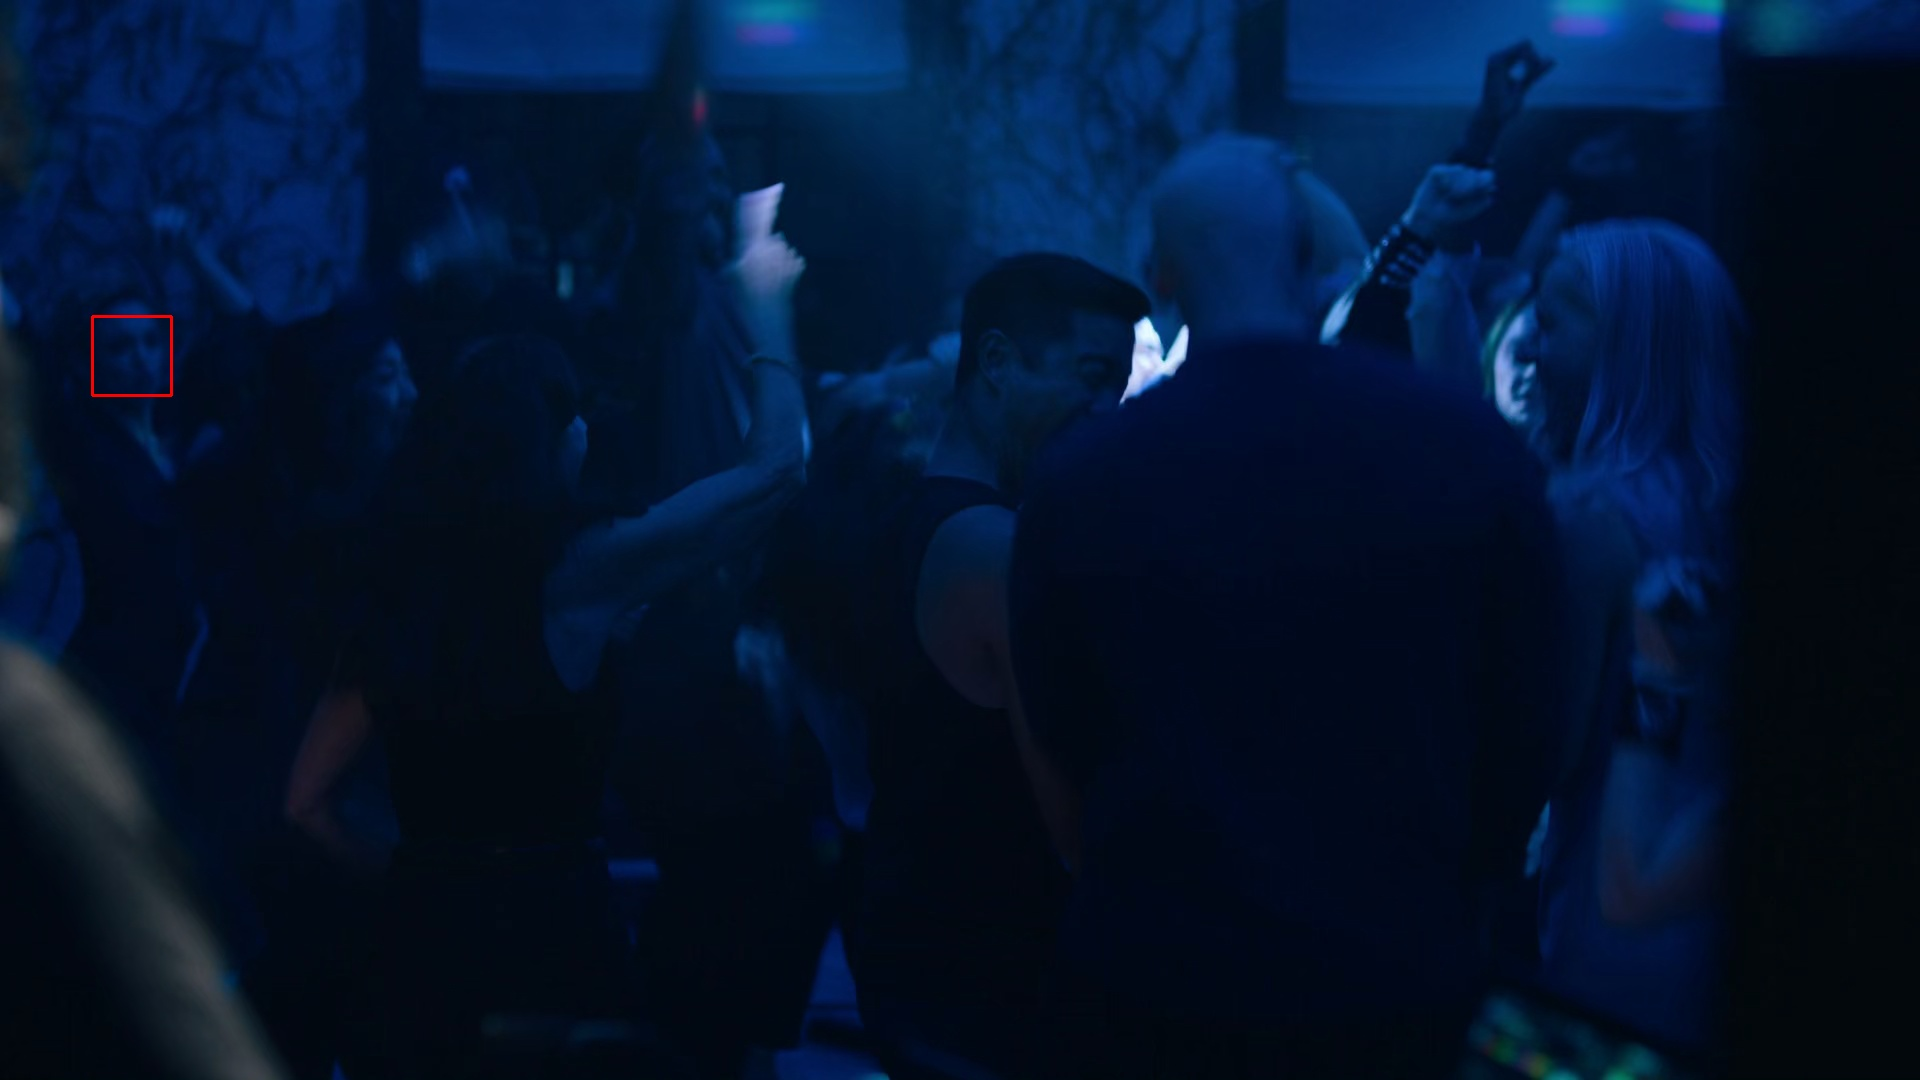

In [16]:
name = 'Billions.S06E10.1080p.WEBRip.x265-RARBG_73680.png'
show_faces(name)

In [23]:
src = '../test_images/Modern.Family.S01E10.1080p.BluRay.x265-RARBG_17328.png'
img = cv2.imread(src)
faces = det(img)
faces

mmod_rectangles[[(757, 228) (993, 464)], [(823, 284) (959, 420)]]

In [25]:
face = faces[0]
x, y, w, h = face.rect.left(), face.rect.top(), face.rect.right(), face.rect.bottom()

In [26]:
face = faces[1]
x2, y2, w2, h2 = face.rect.left(), face.rect.top(), face.rect.right(), face.rect.bottom()

In [31]:
if x2 > x and w2 < w:
    print('inside')
else:
    print('not inside')

inside


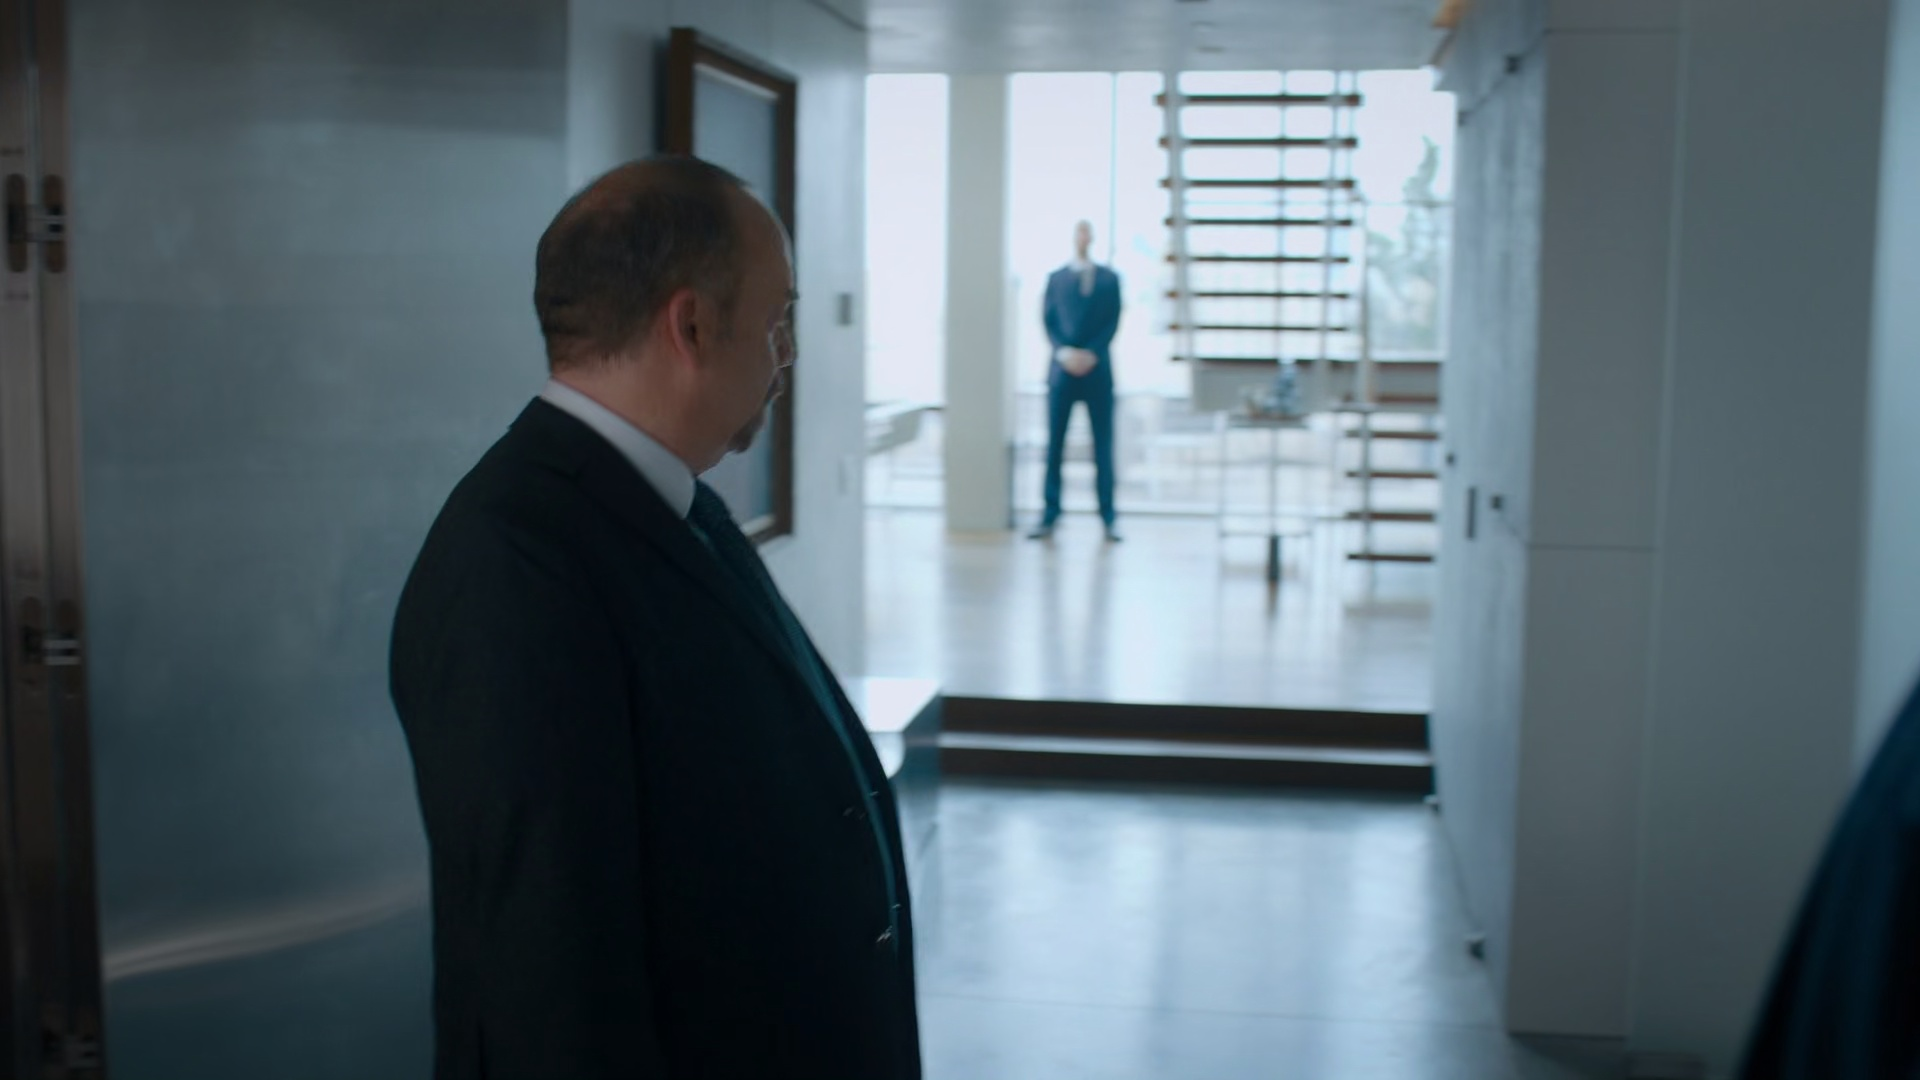

In [7]:
src = '../test_images/Billions.S04E02.1080p.WEBRip.x265-RARBG_52416.png'
img = cv2.imread(src)
faces = det(img)
draw_faces(img, faces)
show_image(img)

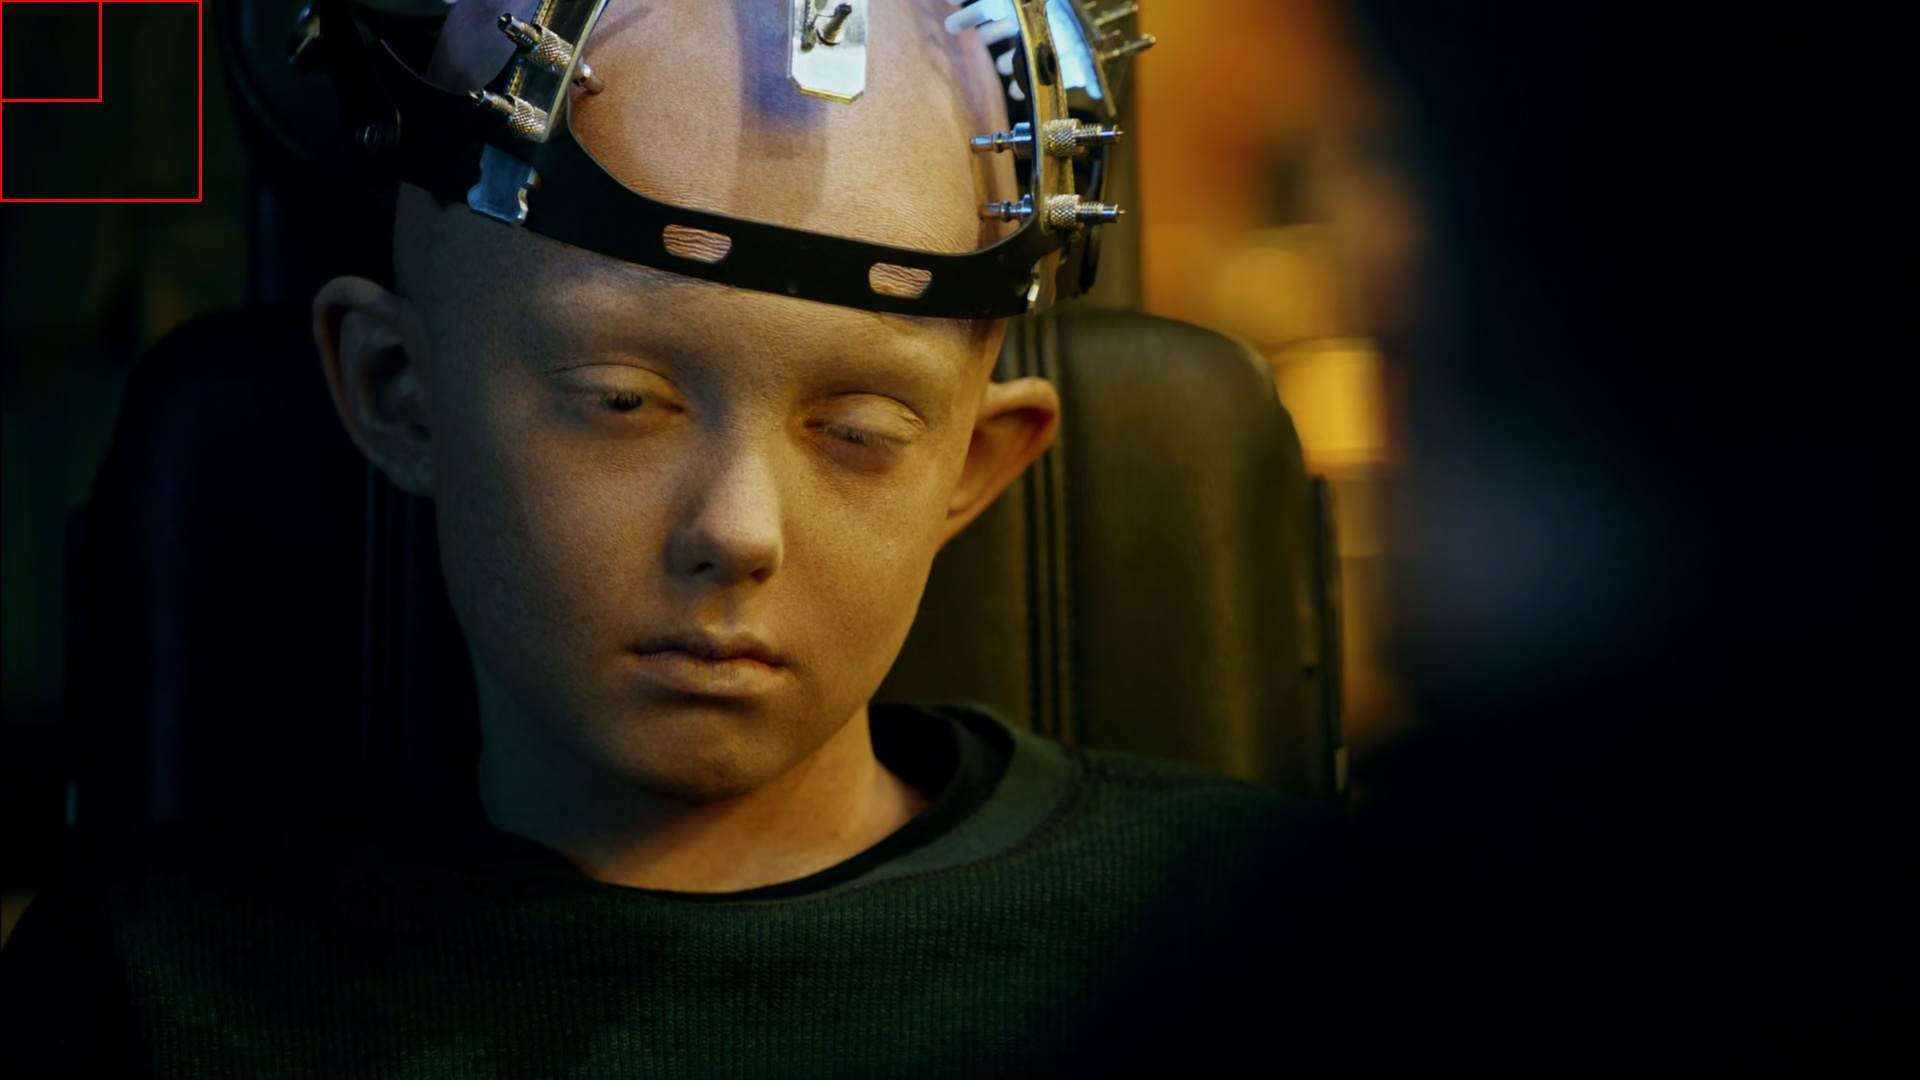

In [19]:
img = cv2.imread('../test_images/Fringe.S05E10.Anomaly.XB-6783746.1080p.BluRay.10bit.x265.HEVC.DD.5.1-PHOCiS_59472.png')
cv2.rectangle(img, (0, 0), (200, 200), (0, 0, 255), 2)
cv2.rectangle(img, (0, 0), (100, 100), (0, 0, 255), 2)
show_image(img)